In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Adicionando a pasta raiz ao path para conseguir importar a pasta mlp
sys.path.append(os.path.abspath('..'))

from mlp.network import MLP, LinearLayer
from mlp.activations import ReLU, Softmax
from mlp.optimizers import train, train_with_history

In [2]:
import os
import urllib.request
import numpy as np

# Define o caminho para salvar o arquivo de dados localmente
data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, 'mnist.npz')

# Faz o download direto do arquivo bruto do MNIST se ele não existir localmente
if not os.path.exists(data_path):
    print("Baixando o dataset MNIST via URL direta...")
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
    urllib.request.urlretrieve(url, data_path)
    print("Download concluído com sucesso!")

# Carrega as matrizes nativamente usando apenas o NumPy
with np.load(data_path) as data:
    x_train = data['x_train']
    y_train = data['y_train']
    x_test = data['x_test']
    y_test = data['y_test']

# Pré-processamento manual idêntico ao original:
# 1. Flatten e Normalização (0 a 1)
x_train = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.0
x_test = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.0

# 2. One-hot encoding das labels
def to_one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_oh = to_one_hot(y_train)
y_test_oh = to_one_hot(y_test)

print(f"Dados carregados com sucesso utilizando 100% NumPy!")
print(f"Formato dos dados de Treino: {x_train.shape}, Teste: {x_test.shape}")

Dados carregados com sucesso utilizando 100% NumPy!
Formato dos dados de Treino: (60000, 784), Teste: (10000, 784)


In [3]:
def evaluate(model, x, y):
    preds = np.argmax(model.forward(x), axis=1)
    return np.mean(preds == y)

final_model = MLP()
final_model.add_layer(LinearLayer(784, 128, 0.1), ReLU())
final_model.add_layer(LinearLayer(128, 64, 0.1), ReLU())
final_model.add_layer(LinearLayer(64, 10, 0.1), Softmax())

losses = train_with_history(final_model, x_train, y_train_oh)

print(f"\nTeste Acc: {evaluate(final_model, x_test, y_test)*100:.2f}%")

Epoch 1 Loss: 0.2609
Epoch 2 Loss: 0.1293
Epoch 3 Loss: 0.0981
Epoch 4 Loss: 0.0812
Epoch 5 Loss: 0.0711

Teste Acc: 96.72%


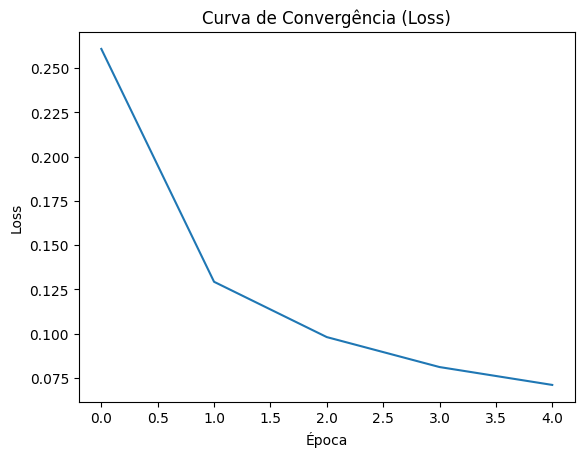

In [4]:
plt.plot(losses)
plt.title('Curva de Convergência (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')

# Salvando a figura na pasta de results como pedido
plt.savefig('../results/curva_de_loss.png')
plt.show()

## Adiciona Mais Experimentos

### Learning Rates

Iniciando o experimento de Taxas de Aprendizado...
-> Treinando com Learning Rate = 0.1
Epoch 1 Loss: 0.2585
Epoch 2 Loss: 0.1263
Epoch 3 Loss: 0.0972
Epoch 4 Loss: 0.0791
Epoch 5 Loss: 0.0740
-> Treinando com Learning Rate = 0.01
Epoch 1 Loss: 0.3704
Epoch 2 Loss: 0.1565
Epoch 3 Loss: 0.1109
Epoch 4 Loss: 0.0873
Epoch 5 Loss: 0.0706
-> Treinando com Learning Rate = 0.001
Epoch 1 Loss: 0.9149
Epoch 2 Loss: 0.3687
Epoch 3 Loss: 0.3062
Epoch 4 Loss: 0.2728
Epoch 5 Loss: 0.2477


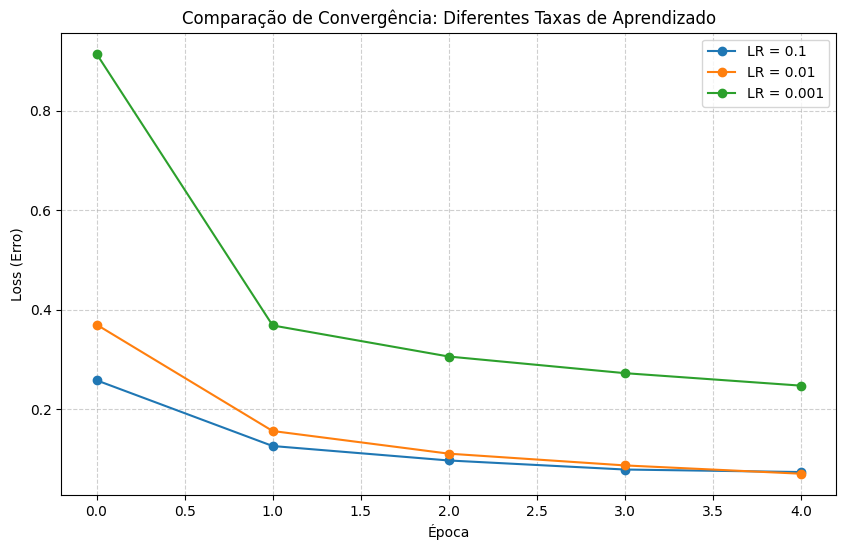

Gráfico 'comparacao_learning_rates.png' salvo com sucesso em results!


In [5]:
import matplotlib.pyplot as plt
from mlp.network import MLP, LinearLayer
from mlp.activations import ReLU, Softmax
from mlp.optimizers import train_with_history

# Taxas de aprendizado que vamos testar
learning_rates = [0.1, 0.01, 0.001]
resultados_lr = {}

print("Iniciando o experimento de Taxas de Aprendizado...")

for lr in learning_rates:
    print(f"-> Treinando com Learning Rate = {lr}")
    # Instancia uma nova rede para cada teste
    modelo_teste = MLP()
    modelo_teste.add_layer(LinearLayer(784, 128, learning_rate=lr), ReLU())
    modelo_teste.add_layer(LinearLayer(128, 64, learning_rate=lr), ReLU())
    modelo_teste.add_layer(LinearLayer(64, 10, learning_rate=lr), Softmax())
    
    # Treina por 5 épocas
    historico_loss = train_with_history(modelo_teste, x_train, y_train_oh, epochs=5, batch_size=64)
    resultados_lr[lr] = historico_loss

# Gerar e salvar o gráfico comparativo
plt.figure(figsize=(10, 6))
for lr, losses in resultados_lr.items():
    plt.plot(losses, marker='o', label=f'LR = {lr}')

plt.title('Comparação de Convergência: Diferentes Taxas de Aprendizado')
plt.xlabel('Época')
plt.ylabel('Loss (Erro)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Salvando na pasta results (subindo um nível com '../')
plt.savefig('../results/comparacao_learning_rates.png', bbox_inches='tight')
plt.show()
print("Gráfico 'comparacao_learning_rates.png' salvo com sucesso em results!")

### Matriz de Confusão

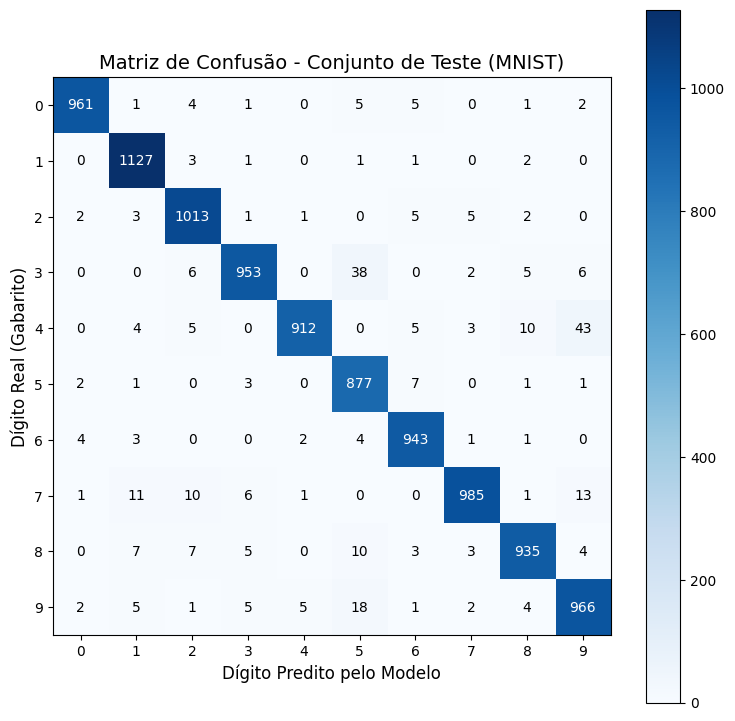

Gráfico 'matriz_confusao.png' salvo com sucesso em results!


In [6]:
# Obtém as previsões do modelo final para o conjunto de teste
previsoes_brutas = final_model.forward(x_test)
preds = np.argmax(previsoes_brutas, axis=1)

# Cria uma matriz 10x10 preenchida com zeros usando NumPy
matriz_confusao = np.zeros((10, 10), dtype=int)

# Preenche a matriz comparando o valor Real com o Predito
for real, predito in zip(y_test, preds):
    matriz_confusao[real, predito] += 1

# Plotar a matriz graficamente
plt.figure(figsize=(9, 9))
plt.imshow(matriz_confusao, cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste (MNIST)', fontsize=14)
plt.colorbar()

tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel('Dígito Predito pelo Modelo', fontsize=12)
plt.ylabel('Dígito Real (Gabarito)', fontsize=12)

# Escreve os números dentro dos quadrados da matriz
limiar = matriz_confusao.max() / 2.0
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(matriz_confusao[i, j]),
                 ha="center", va="center",
                 color="white" if matriz_confusao[i, j] > limiar else "black")

# Salvando na pasta results
plt.savefig('../results/matriz_confusao.png', bbox_inches='tight')
plt.show()
print("Gráfico 'matriz_confusao.png' salvo com sucesso em results!")

### Identificação de Erros

Total de erros no conjunto de teste: 328 de 10000


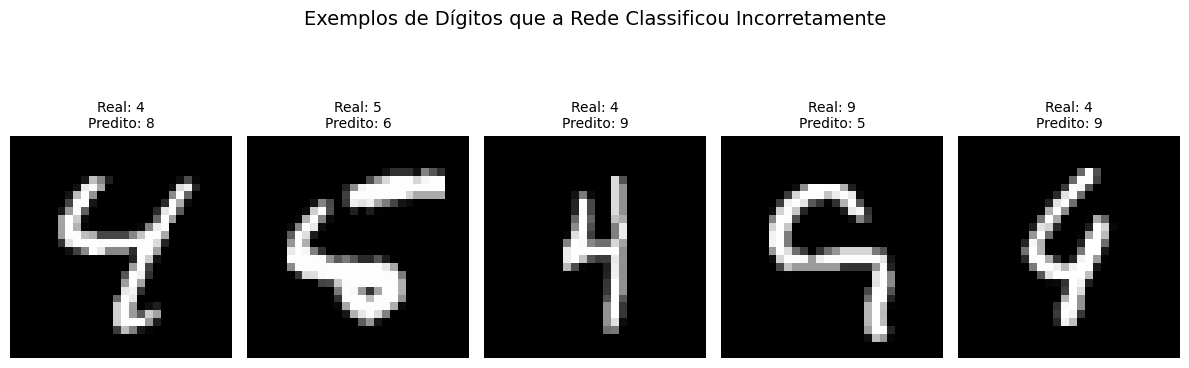

Gráfico 'exemplos_erros_modelo.png' salvo com sucesso em results!


In [7]:
# Encontra os índices onde a previsão foi diferente do gabarito real
indices_erros = np.where(preds != y_test)[0]

print(f"Total de erros no conjunto de teste: {len(indices_erros)} de {len(y_test)}")

# Vamos desenhar os 5 primeiros erros encontrados
plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices_erros[:5]):
    plt.subplot(1, 5, i + 1)
    
    # Como os dados foram achatados para (784,), mudamos o formato de volta para (28, 28) para exibir
    imagem_digito = x_test[idx].reshape(28, 28)
    
    plt.imshow(imagem_digito, cmap='gray')
    plt.title(f"Real: {y_test[idx]}\nPredito: {preds[idx]}", fontsize=10)
    plt.axis('off')

plt.suptitle('Exemplos de Dígitos que a Rede Classificou Incorretamente', fontsize=14, y=1.05)
plt.tight_layout()

# Salvando na pasta results
plt.savefig('../results/exemplos_erros_modelo.png', bbox_inches='tight')
plt.show()
print("Gráfico 'exemplos_erros_modelo.png' salvo com sucesso em results!")

### Verificação dos Gradientes

In [10]:
def gradient_check_definitivo():
    print("Iniciando Verificação Numérica de Gradientes (Mapeamento Direto)...")
    epsilon = 1e-5
    
    # 1. Dados controlados pequenos para o teste ser rápido e preciso
    np.random.seed(42)
    x_toy = np.random.randn(2, 4)  # 2 amostras, 4 características de entrada
    y_toy = np.array([[1.0, 0.0, 0.0], 
                      [0.0, 1.0, 0.0]]) # One-hot para 3 classes de saída
    
    # 2. Instancia a camada linear isolada e a ativação Softmax
    # Usamos learning_rate=1.0 e momentum=0.0 estritamente para o teste isolar o gradiente puro
    layer = LinearLayer(input_size=4, output_size=3, learning_rate=1.0, momentum=0.0)
    from mlp.activations import Softmax
    from mlp.losses import cross_entropy_loss
    activation = Softmax()
    
    # Fazer uma cópia exata dos pesos iniciais antes de qualquer mutação
    weights_iniciais = layer.weights.copy()
    bias_iniciais = layer.bias.copy()
    
    # 3. PASSO ANALÍTICO (Seu algoritmo)
    out_linear = layer.forward(x_toy)
    out_soft = activation.forward(out_linear)
    
    # Gradiente analítico exato da junção Softmax + CrossEntropy
    grad_output = out_soft - y_toy
    
    # Como o backward altera os pesos internamente, vamos capturar a matemática
    # exata do grad_weights calculando-o de forma idêntica ao que está na sua linha 18:
    grad_analitico_w = np.dot(layer.input.T, grad_output)
    
    # 4. PASSO NUMÉRICO (Aproximação por limites físicos)
    grad_numerico_w = np.zeros_like(weights_iniciais)
    
    # Varre a matriz de pesos aplicando pequenos distúrbios (perturbações)
    for i in range(weights_iniciais.shape[0]):
        for j in range(weights_iniciais.shape[1]):
            
            # Peso + epsilon
            layer.weights = weights_iniciais.copy()
            layer.weights[i, j] += epsilon
            out_pos = activation.forward(layer.forward(x_toy))
            loss_pos = cross_entropy_loss(out_pos, y_toy) * len(x_toy) # Escala para Loss Total
            
            # Peso - epsilon
            layer.weights = weights_iniciais.copy()
            layer.weights[i, j] -= epsilon
            out_pos = activation.forward(layer.forward(x_toy))
            loss_neg = cross_entropy_loss(out_pos, y_toy) * len(x_toy) # Escala para Loss Total
            
            # Calcula a derivada numérica para este peso específico
            grad_numerico_w[i, j] = (loss_pos - loss_neg) / (2 * epsilon)
            
    # Restaura a camada para o estado original imaculado
    layer.weights = weights_iniciais.copy()
    
    # 5. COMPARAÇÃO MATEMÁTICA (Diferença Relativa)
    numerador = np.linalg.norm(grad_analitico_w - grad_numerico_w)
    denominador = np.linalg.norm(grad_analitico_w) + np.linalg.norm(grad_numerico_w)
    diff = numerador / denominador
    
    print(f"Diferença Relativa Obtida: {diff:.2e}")
    if diff < 1e-6:
        print("SUCESSO: O gradiente analítico está correto!")
    else:
        print("ERRO: Verifique as escalas da formulação.")

gradient_check_definitivo()

Iniciando Verificação Numérica de Gradientes (Mapeamento Direto)...
Diferença Relativa Obtida: 1.23e-11
SUCESSO: O gradiente analítico está correto!


### Visualização das Ativações Internas

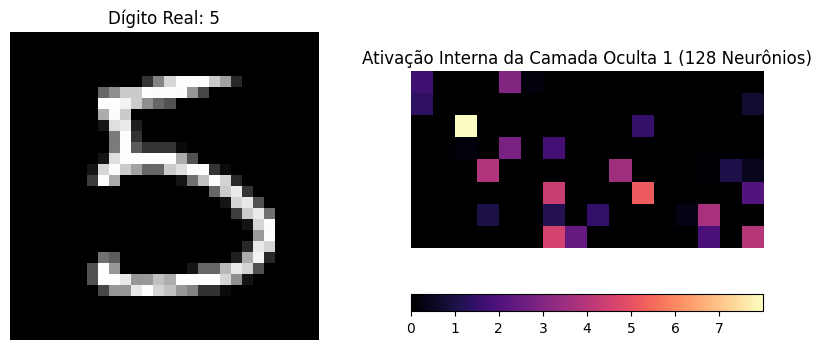

In [11]:
# Escolhe uma imagem de teste (ex: índice 15)
idx_amostra = 15
imagem_vetor = x_test[idx_amostra].reshape(1, -1)

# Passa pela primeira camada e pela primeira ativação ReLU manualmente
ativacao_interna = final_model.activations[0].forward(final_model.layers[0].forward(imagem_vetor))

# Como a camada interna tem 128 neurônios, vamos remodelar em uma matriz 8x16 para visualizar
matriz_ativacao = ativacao_interna.reshape(8, 16)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_test[idx_amostra].reshape(28, 28), cmap='gray')
plt.title(f"Dígito Real: {y_test[idx_amostra]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(matriz_ativacao, cmap='magma')
plt.title("Ativação Interna da Camada Oculta 1 (128 Neurônios)")
plt.colorbar(orientation='horizontal')
plt.axis('off')

plt.savefig('../results/ativacoes_internas.png', bbox_inches='tight')
plt.show()

### Embeddings via PCA 

Calculando Embeddings via PCA do zero com NumPy...


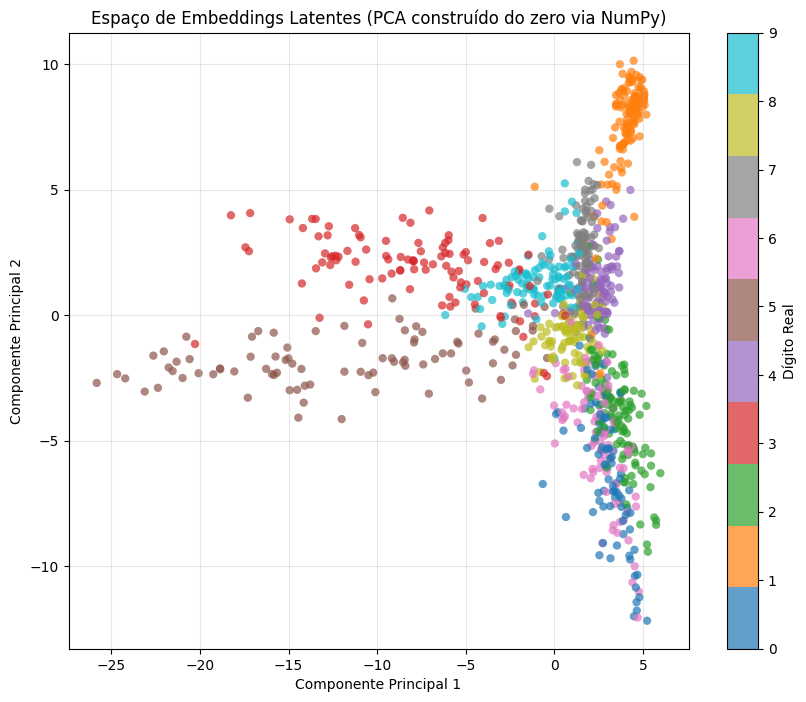

In [ ]:
print("Calculando Embeddings via PCA do zero com NumPy...")

# 1. Extrair os outputs da última camada oculta para as primeiras 1000 imagens de teste
X_features = []
for i in range(1000):
    img = x_test[i].reshape(1, -1)
    # Passa pela Camada 1 -> ReLU -> Camada 2 -> ReLU
    h1 = final_model.activations[0].forward(final_model.layers[0].forward(img))
    h2 = final_model.activations[1].forward(final_model.layers[1].forward(h1))
    X_features.append(h2.flatten())

X_features = np.array(X_features) # Formato (1000, 64)

# 2. Algoritmo PCA NATIVO NUMPY
X_centralizado = X_features - np.mean(X_features, axis=0) # Centraliza na média
matriz_covariancia = np.cov(X_centralizado, rowvar=False)  # Matriz de covariância
valores_proprios, vetores_proprios = np.linalg.eigh(matriz_covariancia) # Autovalores e Autovetores

# Ordena decrescente pelos maiores autovalores (maior variância)
indices_ordenados = np.argsort(valores_proprios)[::-1]
vetores_top2 = vetores_proprios[:, indices_ordenados[:2]]

# Projeta os dados de 64 dimensões para as 2 dimensões principais
X_projetado_2d = np.dot(X_centralizado, vetores_top2)

# 3. Plotagem do Espaço Latente (Embeddings)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_projetado_2d[:, 0], X_projetado_2d[:, 1], c=y_test[:1000], cmap='tab10', alpha=0.7, edgecolors='none')
plt.colorbar(scatter, ticks=range(10), label='Dígito Real')
plt.title('Espaço de Embeddings Latentes (PCA via NumPy)', fontsize=12)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, alpha=0.3)

plt.savefig('../results/embeddings_pca_do_zero.png', bbox_inches='tight')
plt.show()